In [10]:
import pandas as pd
from pathlib import Path

csv_files = sorted(Path("../data/benign_data").glob("*.csv"))
df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)
print(df.info())
df["cert_valid"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 32844 entries, 0 to 32843
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   url                 32844 non-null  str  
 1   final_url           32513 non-null  str  
 2   status_code         32844 non-null  int64
 3   reason              32428 non-null  str  
 4   redirect_count      32844 non-null  int64
 5   html_file           31555 non-null  str  
 6   js_files            26670 non-null  str  
 7   cert_file           32281 non-null  str  
 8   cert_valid          32844 non-null  bool 
 9   cert_error_message  330 non-null    str  
 10  user_agent          32844 non-null  str  
 11  error               32844 non-null  bool 
 12  error_message       331 non-null    str  
dtypes: bool(2), int64(2), str(9)
memory usage: 2.8 MB
None


cert_valid
True     32183
False      661
Name: count, dtype: int64

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Overall error rate first.
error_counts = df["error"].value_counts().reindex([False, True], fill_value=0)

print(f"Total rows: {len(df):,}")
print(f"Rows without error: {error_counts.get(False, 0):,} ({error_counts.get(False, 0) / len(df) * 100:.2f}%)")
print(f"Rows with error: {error_counts.get(True, 0):,} ({error_counts.get(True, 0) / len(df) * 100:.2f}%)")

# Analyze only successful fetches, but do it separately for each user_agent.
df_clean = df[df["error"] == False].copy()
print(f"\n--- Analysis of {len(df_clean):,} rows WITHOUT errors, split by user_agent ---\n")

if "user_agent" not in df_clean.columns:
    raise ValueError("user_agent column is required for this analysis")

ua_list = df_clean["user_agent"].dropna().unique().tolist()

summary_rows = []
for ua in ua_list:
    ua_df = df_clean[df_clean["user_agent"] == ua].copy()
    print(f"\n### user_agent: {ua}")
    print(f"Rows: {len(ua_df):,}")
    print(f"Unique URLs: {ua_df['url'].nunique():,}")
    print(f"Unique final URLs: {ua_df['final_url'].nunique(dropna=True):,}")
    print(f"Mean redirect count: {ua_df['redirect_count'].mean():.2f}")
    print(f"Median redirect count: {ua_df['redirect_count'].median():.2f}")
    print(f"Certificate valid rate: {ua_df['cert_valid'].mean() * 100:.2f}%")

    summary_rows.append({
        "user_agent": ua,
        "rows": len(ua_df),
        "unique_urls": ua_df["url"].nunique(),
        "unique_final_urls": ua_df["final_url"].nunique(dropna=True),
        "redirect_count_mean": round(ua_df["redirect_count"].mean(), 2),
        "redirect_count_median": round(float(ua_df["redirect_count"].median()), 2),
        "cert_valid_rate": round(ua_df["cert_valid"].mean() * 100, 2),
        "rows_with_html_file": int(ua_df["html_file"].notna().sum()),
        "rows_with_js_files": int(ua_df["js_files"].notna().sum()),
        "rows_with_cert_file": int(ua_df["cert_file"].notna().sum()),
    })

    quality_ua = pd.DataFrame({
        "metric": [
            "unique_urls",
            "unique_final_urls",
            "redirect_count_mean",
            "redirect_count_median",
            "cert_valid_rate",
            "rows_with_html_file",
            "rows_with_js_files",
            "rows_with_cert_file",
        ],
        "value": [
            ua_df["url"].nunique(),
            ua_df["final_url"].nunique(),
            round(ua_df["redirect_count"].mean(), 2),
            float(ua_df["redirect_count"].median()),
            round(ua_df["cert_valid"].mean() * 100, 2),
            int(ua_df["html_file"].notna().sum()),
            int(ua_df["js_files"].notna().sum()),
            int(ua_df["cert_file"].notna().sum()),
        ],
    })
    display(quality_ua)

    status_counts_ua = ua_df["status_code"].value_counts().sort_index()
    display(status_counts_ua.to_frame("count"))

    display(ua_df["redirect_count"].describe().to_frame().T)

summary_df = pd.DataFrame(summary_rows).sort_values("rows", ascending=False)
print("\n--- Per user_agent summary (clean data) ---")
display(summary_df)


Total rows: 53,305
Rows without error: 45,696 (85.73%)
Rows with error: 7,609 (14.27%)

--- Analysis of 45,696 rows WITHOUT errors, split by user_agent ---


### user_agent: desktop
Rows: 6,543
Unique URLs: 6,543
Unique final URLs: 5,910
Mean redirect count: 0.15
Median redirect count: 0.00
Certificate valid rate: 95.58%


,metric,value
0,unique_urls,6543.00
1,unique_final_urls,5910.00
2,redirect_count_mean,0.15
3,redirect_count_median,0.00
4,cert_valid_rate,95.58
5,rows_with_html_file,6253.00
6,rows_with_js_files,4486.00
7,rows_with_cert_file,6327.00


,count
status_code,
200,4626
202,2
400,9
401,4
402,1
403,966
404,791
406,3
410,10


,count,mean,std,min,25%,50%,75%,max
redirect_count,6543.0,0.153905,0.43537,0.0,0.0,0.0,0.0,5.0



### user_agent: android
Rows: 6,546
Unique URLs: 6,546
Unique final URLs: 5,900
Mean redirect count: 0.17
Median redirect count: 0.00
Certificate valid rate: 95.55%


...

,metric,value
0,unique_urls,6476.00
1,unique_final_urls,5851.00
2,redirect_count_mean,0.15
3,redirect_count_median,0.00
4,cert_valid_rate,95.61
5,rows_with_html_file,6179.00
6,rows_with_js_files,4298.00
7,rows_with_cert_file,6260.00


,count
status_code,
200,4429
202,2
401,7
402,1
403,1078
404,803
406,3
410,11
429,47


,count,mean,std,min,25%,50%,75%,max
redirect_count,6476.0,0.151482,0.439796,0.0,0.0,0.0,0.0,4.0



--- Per user_agent summary (clean data) ---


,user_agent,rows,unique_urls,unique_final_urls,redirect_count_mean,redirect_count_median,cert_valid_rate,rows_with_html_file,rows_with_js_files,rows_with_cert_file
1,android,6546,6546,5900,0.17,0.0,95.55,6270,4504,6328
0,desktop,6543,6543,5910,0.15,0.0,95.58,6253,4486,6327
2,bot,6534,6534,5893,0.16,0.0,95.55,6224,4418,6312
3,amazonaws,6533,6533,5885,0.16,0.0,95.64,6253,4478,6317
4,phishtank,6532,6532,5890,0.16,0.0,95.55,6255,4465,6310
5,google,6532,6532,5888,0.16,0.0,95.61,6262,4435,6313
6,curl,6476,6476,5851,0.15,0.0,95.61,6179,4298,6260


Unique URLs with desktop reference: 4692
Compared non-desktop rows (URL + user_agent): 27805
Rows with differences vs desktop: 65
Unique URLs with at least one difference: 35

Rows where at least one field differs from desktop:


,url,user_agent,final_url,error,final_domain,final_url_ref_domain,final_url_ref,error_ref,diff_final_url,diff_error
23228,https://www.freepik.es/fotos/tren-alta-velocidad,amazonaws,https://www.magnific.com/es/fotos/tren-alta-ve...,False,magnific.com,freepik.es,https://www.freepik.es/fotos/tren-alta-velocidad,False,True,False
23226,https://www.freepik.es/fotos/tren-alta-velocidad,android,https://www.magnific.com/es/fotos/tren-alta-ve...,False,magnific.com,freepik.es,https://www.freepik.es/fotos/tren-alta-velocidad,False,True,False
2905,https://aguea.net/MAPFRE,bot,https://vanlett.com/MAPFRE,False,vanlett.com,aguea.net,https://aguea.net/jschallenge?r=/MAPFRE,False,True,False
16873,https://bentoncityedc.org/article/mikel-landa-...,bot,https://bentoncityedc.org/article/mikel-landa-...,False,bentoncityedc.org,custommapposter.com,https://custommapposter.com/article/mikel-land...,False,True,False
8257,https://catgrassina.org/article/kenya-s-sabast...,bot,https://catgrassina.org/article/kenya-s-sabast...,False,catgrassina.org,custommapposter.com,https://custommapposter.com/article/kenya-s-sa...,False,True,False
...,...,...,...,...,...,...,...,...,...,...
11393,https://www.gettyimages.com/photos/soraya-saen...,curl,https://www.gettyimages.com/bot-wall?returnUrl...,False,gettyimages.com,gettyimages.es,https://www.gettyimages.es/bot-wall?returnUrl=...,False,True,False
23681,https://www.gettyimages.com/photos/tomas-marti...,curl,https://www.gettyimages.com/bot-wall?returnUrl...,False,gettyimages.com,gettyimages.es,https://www.gettyimages.es/bot-wall?returnUrl=...,False,True,False
19901,https://www.gettyimages.com/photos/willy-bárcenas,curl,https://www.gettyimages.com/bot-wall?returnUrl...,False,gettyimages.com,gettyimages.es,https://www.gettyimages.es/bot-wall?returnUrl=...,False,True,False
23230,https://www.freepik.es/fotos/tren-alta-velocidad,google,https://www.magnific.com/es/fotos/tren-alta-ve...,False,magnific.com,freepik.es,https://www.freepik.es/fotos/tren-alta-velocidad,False,True,False



Difference counts by user_agent:


,different_url_queries
user_agent,
bot,34
curl,27
android,1
amazonaws,1
google,1
phishtank,1



Field-level difference counts by user_agent:


,final_url,error
user_agent,,
amazonaws,1,0
android,1,0
bot,34,0
curl,27,0
google,1,0
phishtank,1,0


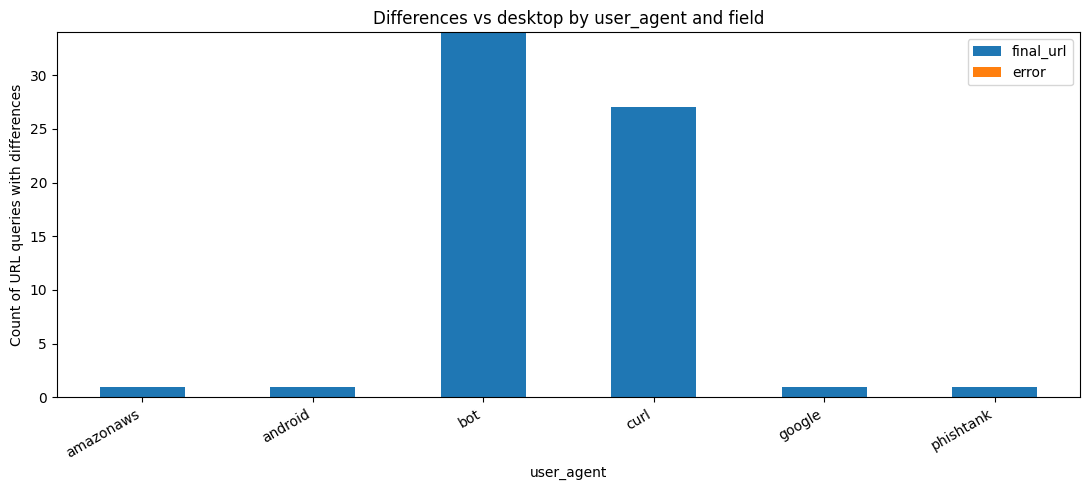

In [39]:
import matplotlib.pyplot as plt
from IPython.display import display
from urllib.parse import urlparse

# Confirm required columns from the known schema.
required_cols = [
    "url",
    "user_agent",
    "status_code",
    "reason",
    "redirect_count",
    "final_url",
    "error",
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")


def extract_base_domain(value):
    """Return registrable-like domain without protocol, subdomain, or path."""
    if pd.isna(value):
        return "<NA>"

    raw = str(value).strip()
    if not raw:
        return "<NA>"

    # Allow host-only strings without scheme.
    if "://" not in raw:
        raw = f"http://{raw}"

    host = (urlparse(raw).hostname or "").lower().strip(".")
    if not host:
        return "<NA>"

    parts = host.split(".")
    if len(parts) <= 2:
        return host

    return ".".join(parts[-2:])


url_col = "url"
ua_col = "user_agent"
metric_cols = ["final_url", "error"]

# Keep one row per (url, user_agent) for a clean comparison surface.
base_df = df[[url_col, ua_col] + metric_cols].copy()
base_df = base_df.drop_duplicates(subset=[url_col, ua_col], keep="first")

# Desktop is the reference profile for each URL.
desktop_ref = (
    base_df[base_df[ua_col] == "desktop"][[url_col] + metric_cols]
    .drop_duplicates(subset=[url_col], keep="first")
    .rename(columns={c: f"{c}_ref" for c in metric_cols})
)

to_compare = base_df[base_df[ua_col] != "desktop"].copy()
comparison = to_compare.merge(desktop_ref, on=url_col, how="inner")

# Compare final_url by domain only.
comparison["final_domain"] = comparison["final_url"].apply(extract_base_domain)
comparison["final_url_ref_domain"] = comparison["final_url_ref"].apply(extract_base_domain)

# Drop rows where either domain is missing or placeholder.
domain_mask = (
    comparison["final_domain"].notna()
    & comparison["final_url_ref_domain"].notna()
    & (comparison["final_domain"] != "<NA>")
    & (comparison["final_url_ref_domain"] != "<NA>")
)
comparison = comparison[domain_mask].copy()

for c in metric_cols:
    if c == "final_url":
        comparison[f"diff_{c}"] = comparison["final_domain"] != comparison["final_url_ref_domain"]
    else:
        comparison[f"diff_{c}"] = (
            comparison[c].fillna("<NA>").astype(str)
            != comparison[f"{c}_ref"].fillna("<NA>").astype(str)
        )

diff_flag_cols = [f"diff_{c}" for c in metric_cols]
comparison["any_diff"] = comparison[diff_flag_cols].any(axis=1)
differences = comparison[comparison["any_diff"]].copy()

print(f"Unique URLs with desktop reference: {desktop_ref[url_col].nunique()}")
print(f"Compared non-desktop rows (URL + user_agent): {len(comparison)}")
print(f"Rows with differences vs desktop: {len(differences)}")
print(f"Unique URLs with at least one difference: {differences[url_col].nunique()}")

if differences.empty:
    print("No differences detected across user_agent labels compared to desktop.")
else:
    print("\nRows where at least one field differs from desktop:")
    display(
        differences[
            [url_col, ua_col]
            + metric_cols
            + ["final_domain", "final_url_ref_domain"]
            + [f"{c}_ref" for c in metric_cols]
            + diff_flag_cols
        ].sort_values([ua_col, url_col])
    )

    summary_by_ua = (
        differences.groupby(ua_col)
        .size()
        .sort_values(ascending=False)
        .rename("different_url_queries")
        .to_frame()
    )
    print("\nDifference counts by user_agent:")
    display(summary_by_ua)

    metric_diff_by_ua = differences.groupby(ua_col)[diff_flag_cols].sum().sort_index()
    metric_diff_by_ua.columns = [c.replace("diff_", "") for c in metric_diff_by_ua.columns]

    print("\nField-level difference counts by user_agent:")
    display(metric_diff_by_ua)

    ax = metric_diff_by_ua.plot(kind="bar", stacked=True, figsize=(11, 5))
    ax.set_title("Differences vs desktop by user_agent and field")
    ax.set_xlabel("user_agent")
    ax.set_ylabel("Count of URL queries with differences")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [5]:
from urllib.parse import urlparse
import pandas as pd
from IPython.display import display

def extract_base_domain(value: str) -> str | None:
    if pd.isna(value):
        return None

    raw = str(value).strip()
    if not raw:
        return None

    if "://" not in raw:
        raw = f"http://{raw}"

    host = (urlparse(raw).hostname or "").lower().strip(".")
    if not host:
        return None

    parts = host.split(".")
    if len(parts) <= 2:
        return host

    return ".".join(parts[-2:])

top_n = 30
unique_urls = pd.Series(df["url"].dropna().unique())
unique_final_urls = pd.Series(df["final_url"].dropna().unique())

url_domains = unique_urls.map(extract_base_domain).dropna()
final_domains = unique_final_urls.map(extract_base_domain).dropna()

url_domain_counts = url_domains.value_counts().head(top_n).to_frame("count")
final_domain_counts = final_domains.value_counts().head(top_n).to_frame("count")

print(f"Top {top_n} base domains from unique url values:")
display(url_domain_counts)

print(f"Top {top_n} base domains from unique final_url values:")
display(final_domain_counts)

Top 30 base domains from unique url values:


,count
wikipedia.org,469
grokipedia.com,232
youtube.com,106
pinterest.com,81
co.uk,71
instagram.com,69
google.com,58
tiktok.com,55
sofascore.com,52
imdb.com,40


Top 30 base domains from unique final_url values:


,count
wikipedia.org,469
google.com,318
youtube.com,295
grokipedia.com,232
pinterest.com,81
instagram.com,69
co.uk,66
tiktok.com,56
sofascore.com,52
imdb.com,40


# Certficate analysis

In [5]:
from pathlib import Path
from datetime import datetime, timezone
import re

import pandas as pd
from IPython.display import display

from cryptography import x509
from cryptography.hazmat.primitives.asymmetric import rsa, ec, dsa
from cryptography.x509.oid import NameOID


CERT_DIRS = {
    "benign": Path("../data/benign_data/CERT"),
    "phish": Path("../data/phish_data/CERT"),
}
ALLOWED_SUFFIXES = {".pem", ".crt", ".cer", ".der", ".cert", ".txt", ""}
PEM_RE = re.compile(
    br"-----BEGIN CERTIFICATE-----.*?-----END CERTIFICATE-----",
    flags=re.DOTALL,
)

VALIDATION_POLICY_OIDS = {
    "EV": {"2.23.140.1.1"},
    "OV": {"2.23.140.1.2.2"},
    "DV": {"2.23.140.1.2.1"},
}


def iter_certs_from_file(path: Path):
    data = path.read_bytes()
    if PEM_RE.search(data):
        for match in PEM_RE.finditer(data):
            try:
                yield x509.load_pem_x509_certificate(match.group(0)), None
            except Exception as exc:
                yield None, f"pem_parse_error: {exc}"
    else:
        try:
            yield x509.load_der_x509_certificate(data), None
        except Exception as exc:
            yield None, f"der_parse_error: {exc}"


def safe_name_attr(name, oid):
    values = name.get_attributes_for_oid(oid)
    if not values:
        return None
    return values[0].value


def extract_policy_oids(cert):
    try:
        ext = cert.extensions.get_extension_for_class(x509.CertificatePolicies)
    except x509.ExtensionNotFound:
        return []
    return [policy.policy_identifier.dotted_string for policy in ext.value]


def classify_validation(policy_oids, subject):
    if any(oid in VALIDATION_POLICY_OIDS["EV"] for oid in policy_oids):
        return "EV", "policy_oid"
    if any(oid in VALIDATION_POLICY_OIDS["OV"] for oid in policy_oids):
        return "OV", "policy_oid"
    if any(oid in VALIDATION_POLICY_OIDS["DV"] for oid in policy_oids):
        return "DV", "policy_oid"

    has_org = bool(subject.get_attributes_for_oid(NameOID.ORGANIZATION_NAME))
    has_jurisdiction = bool(
        subject.get_attributes_for_oid(NameOID.JURISDICTION_COUNTRY_NAME)
        or subject.get_attributes_for_oid(NameOID.JURISDICTION_STATE_OR_PROVINCE_NAME)
        or subject.get_attributes_for_oid(NameOID.JURISDICTION_LOCALITY_NAME)
    )
    if has_jurisdiction:
        return "EV", "subject_jurisdiction"
    if has_org:
        return "OV", "subject_organization"
    return "DV", "subject_no_organization"


def get_san_info(cert):
    try:
        ext = cert.extensions.get_extension_for_class(x509.SubjectAlternativeName)
    except x509.ExtensionNotFound:
        return {
            "san_total": 0,
            "san_dns": 0,
            "san_ip": 0,
            "san_email": 0,
            "san_uri": 0,
            "san_has_wildcard": False,
        }

    names = ext.value
    dns = names.get_values_for_type(x509.DNSName)
    ip = names.get_values_for_type(x509.IPAddress)
    email = names.get_values_for_type(x509.RFC822Name)
    uri = names.get_values_for_type(x509.UniformResourceIdentifier)
    return {
        "san_total": len(dns) + len(ip) + len(email) + len(uri),
        "san_dns": len(dns),
        "san_ip": len(ip),
        "san_email": len(email),
        "san_uri": len(uri),
        "san_has_wildcard": any("*" in entry for entry in dns),
    }


def get_basic_constraints(cert):
    try:
        ext = cert.extensions.get_extension_for_class(x509.BasicConstraints)
        return ext.value.ca, ext.value.path_length
    except x509.ExtensionNotFound:
        return None, None


def to_utc(dt_value):
    if dt_value is None:
        return None
    if dt_value.tzinfo is None:
        return dt_value.replace(tzinfo=timezone.utc)
    return dt_value.astimezone(timezone.utc)


def extract_cert_fields(cert):
    nb = getattr(cert, "not_valid_before_utc", None) or cert.not_valid_before
    na = getattr(cert, "not_valid_after_utc", None) or cert.not_valid_after
    nb = to_utc(nb)
    na = to_utc(na)
    validity_days = (na - nb).days if nb and na else None
    now = datetime.now(timezone.utc)

    public_key = cert.public_key()
    key_type = type(public_key).__name__
    key_size = None
    key_curve = None
    if isinstance(public_key, rsa.RSAPublicKey):
        key_type = "RSA"
        key_size = public_key.key_size
    elif isinstance(public_key, ec.EllipticCurvePublicKey):
        key_type = "EC"
        key_size = public_key.key_size
        key_curve = getattr(public_key.curve, "name", None)
    elif isinstance(public_key, dsa.DSAPublicKey):
        key_type = "DSA"
        key_size = public_key.key_size

    policy_oids = extract_policy_oids(cert)
    validation_type, validation_source = classify_validation(policy_oids, cert.subject)

    is_ca, path_len = get_basic_constraints(cert)

    signature_hash = None
    try:
        signature_hash = cert.signature_hash_algorithm.name
    except Exception:
        signature_hash = None

    san_info = get_san_info(cert)

    return {
        "serial_number": hex(cert.serial_number),
        "version": cert.version.name,
        "subject_common_name": safe_name_attr(cert.subject, NameOID.COMMON_NAME),
        "subject_organization": safe_name_attr(cert.subject, NameOID.ORGANIZATION_NAME),
        "subject_country": safe_name_attr(cert.subject, NameOID.COUNTRY_NAME),
        "issuer_common_name": safe_name_attr(cert.issuer, NameOID.COMMON_NAME),
        "issuer_organization": safe_name_attr(cert.issuer, NameOID.ORGANIZATION_NAME),
        "issuer_country": safe_name_attr(cert.issuer, NameOID.COUNTRY_NAME),
        "not_before": nb.isoformat() if nb else None,
        "not_after": na.isoformat() if na else None,
        "validity_days": validity_days,
        "is_expired": bool(na and now > na),
        "is_valid_now": bool(nb and na and nb <= now <= na),
        "is_self_signed": cert.subject == cert.issuer,
        "is_ca": is_ca,
        "path_len": path_len,
        "signature_algorithm_oid": cert.signature_algorithm_oid.dotted_string,
        "signature_hash": signature_hash,
        "key_type": key_type,
        "key_size": key_size,
        "key_curve": key_curve,
        "validation_type": validation_type,
        "validation_source": validation_source,
        "policy_oids": ";".join(policy_oids),
        **san_info,
    }


rows = []
for label, cert_dir in CERT_DIRS.items():
    if not cert_dir.exists():
        print(f"Missing directory: {cert_dir}")
        continue

    cert_files = [p for p in cert_dir.rglob("*") if p.is_file()]
    print(f"{label}: {len(cert_files):,} files found")

    for path in cert_files:
        if path.suffix.lower() not in ALLOWED_SUFFIXES:
            continue

        parsed_any = False
        for idx, (cert, error) in enumerate(iter_certs_from_file(path)):
            parsed_any = True
            row = {
                "label": label,
                "source_file": str(path),
                "cert_index": idx,
                "parse_error": error,
            }
            if cert is None:
                rows.append(row)
                continue

            row.update(extract_cert_fields(cert))
            rows.append(row)

        if not parsed_any:
            rows.append(
                {
                    "label": label,
                    "source_file": str(path),
                    "cert_index": 0,
                    "parse_error": "no_certificate_found",
                }
            )

cert_df = pd.DataFrame(rows)
print(f"Total parsed rows: {len(cert_df):,}")
print("Parse errors by label:")
parse_summary = (
    cert_df["parse_error"].fillna("ok").value_counts().to_frame("count")
)
display(parse_summary)

if not cert_df.empty:
    cert_df["issuer_name"] = cert_df["issuer_organization"].fillna(
        cert_df["issuer_common_name"]
    )

leaf_df = cert_df[(cert_df["parse_error"].isna()) & (cert_df["is_ca"] == False)].copy()
print(f"Leaf certificates (non-CA): {len(leaf_df):,}")

print("\nValidation type distribution (leafs):")
validation_counts = (
    leaf_df.groupby(["label", "validation_type"]).size().unstack(fill_value=0)
)
display(validation_counts)

print("\nValidation source distribution (leafs):")
validation_source_counts = (
    leaf_df.groupby(["label", "validation_source"]).size().unstack(fill_value=0)
)
display(validation_source_counts)

print("\nValidity period (days) summary (leafs):")
validity_summary = leaf_df.groupby("label")["validity_days"].describe()
display(validity_summary)

print("\nSAN total counts summary (leafs):")
san_summary = leaf_df.groupby("label")["san_total"].describe()
display(san_summary)

print("\nWildcard SAN rate (leafs):")
wildcard_rate = leaf_df.groupby("label")["san_has_wildcard"].mean().to_frame(
    "wildcard_rate"
)
display(wildcard_rate)

print("\nKey types and sizes (leafs, top 20):")
key_summary = (
    leaf_df.groupby(["label", "key_type", "key_size"]).size().reset_index(name="count")
)
key_summary = key_summary.sort_values(["label", "count"], ascending=[True, False])
display(key_summary.head(20))

print("\nTop issuers by label (leafs, top 10 each):")
issuer_summary = (
    leaf_df.groupby(["label", "issuer_name"]).size().reset_index(name="count")
)
issuer_summary = issuer_summary.sort_values(["label", "count"], ascending=[True, False])
for label in issuer_summary["label"].unique():
    display(issuer_summary[issuer_summary["label"] == label].head(10))

benign: 1,802 files found
phish: 1,717 files found
Total parsed rows: 3,517
Parse errors by label:


benign: 1,802 files found
phish: 1,717 files found
Total parsed rows: 3,517
Parse errors by label:


,count
parse_error,
ok,3517


benign: 1,802 files found
phish: 1,717 files found
Total parsed rows: 3,517
Parse errors by label:


,count
parse_error,
ok,3517


...


Key types and sizes (leafs, top 20):


,label,key_type,key_size,count
2,benign,RSA,2048,934
0,benign,EC,256,755
4,benign,RSA,4096,75
1,benign,EC,384,15
3,benign,RSA,3072,10
5,phish,EC,256,1114
7,phish,RSA,2048,494
8,phish,RSA,4096,95
6,phish,EC,384,10



Top issuers by label (leafs, top 10 each):


,label,issuer_name,count
16,benign,Let's Encrypt,677
14,benign,Google Trust Services,515
1,benign,Amazon,163
6,benign,DigiCert Inc,159
21,benign,Sectigo Limited,100
12,benign,GlobalSign nv-sa,65
13,benign,"GoDaddy.com, Inc.",25
5,benign,Certainly,20
9,benign,FNMT-RCM,11
22,benign,Soluciones Corporativas IP SL,9


,label,issuer_name,count
40,phish,Let's Encrypt,1346
39,phish,Google Trust Services,194
28,phish,Amazon,36
34,phish,DigiCert Inc,36
41,phish,Microsoft Corporation,33
47,phish,ZeroSSL,13
43,phish,Sectigo Limited,12
36,phish,GlobalSign nv-sa,10
48,phish,ZeroSSL GmbH,6
37,phish,"GoDaddy.com, Inc.",5


# Flaged phishing filter

In [4]:
from pathlib import Path
import re
from collections import Counter
import time
import json
import pandas as pd

HTML_DIR = Path("data/HTML")
OUTPUT_JSON = Path("data/detected_captcha_phishing_files.json")
FEEDBACK_EVERY = 500

# Filter: status_code == 200 and error == False
df_filtered = df[(df['status_code'] == 200) & (df['error'] == False)].copy()
print(f"Total rows after filtering (status_code == 200 and error == False): {len(df_filtered):,}")

# First pass: collect desktop final_urls by original URL
desktop_final_urls = {}
for idx, row in df_filtered[df_filtered['user_agent'] == 'desktop'].iterrows():
    url = row['url']
    final_url = row.get('final_url')
    if url not in desktop_final_urls and pd.notna(final_url):
        desktop_final_urls[url] = final_url

print(f"Desktop queries with final_url: {len(desktop_final_urls):,}")

# Build set of eligible HTML files based on user_agent and final_url logic
eligible_html_files = {}  # map: filename -> row info for tracking

for idx, row in df_filtered.iterrows():
    user_agent = row['user_agent']
    final_url = row.get('final_url')
    url = row['url']
    html_file = row.get('html_file')

    # Skip if no html_file
    if pd.isna(html_file):
        continue

    # Desktop: always analyze
    if user_agent == 'desktop':
        if html_file not in eligible_html_files:
            eligible_html_files[html_file] = {
                'user_agent': user_agent,
                'url': url,
                'final_url': final_url,
                'reason': 'desktop_query'
            }
    # Other user_agents: only if final_url differs from desktop final_url
    elif pd.notna(final_url) and url in desktop_final_urls:
        desktop_final_url = desktop_final_urls[url]
        if final_url != desktop_final_url:
            if html_file not in eligible_html_files:
                eligible_html_files[html_file] = {
                    'user_agent': user_agent,
                    'url': url,
                    'final_url': final_url,
                    'desktop_final_url': desktop_final_url,
                    'reason': 'final_url_differs_from_desktop'
                }

print(f"Eligible HTML files to analyze: {len(eligible_html_files):,}")

# CAPTCHA_RE exact terms (separated by OR):
# English:
# - attention\s+required!?\s*\|\s*cloudflare
# - cloudflare\s+ray\s+id
# - captcha
# - challenges\.cloudflare\.com/turnstile
# - cf-turnstile
# - verify\s+(you\s+are|you\'re)\s+human
# - are\s+you\s+human
# - you\s+were\s+blocked
# - security\s+check\s+to\s+access
# Spanish:
# - verifica\s+que\s+eres\s+humano
# - verifica\s+que\s+no\s+eres\s+un\s+robot
# - comprueba\s+que\s+eres\s+humano
# - demuestra\s+que\s+eres\s+humano
# - complete\s+la\s+verificaci[o\u00f3]n
# - verificaci[o\u00f3]n\s+de\s+seguridad
# - acceso\s+denegado
# - has\s+sido\s+bloqueado
# - est[\u00e1a]\s+siendo\s+redirigido
CAPTCHA_RE = re.compile(
    r"attention\s+required!?\s*\|\s*cloudflare|cloudflare\s+ray\s+id|captcha|challenges\.cloudflare\.com/turnstile|cf-turnstile|verify\s+(you\s+are|you\'re)\s+human|are\s+you\s+human|you\s+were\s+blocked|security\s+check\s+to\s+access|verifica\s+que\s+eres\s+humano|verifica\s+que\s+no\s+eres\s+un\s+robot|comprueba\s+que\s+eres\s+humano|demuestra\s+que\s+eres\s+humano|complete\s+la\s+verificaci[o\u00f3]n|verificaci[o\u00f3]n\s+de\s+seguridad|acceso\s+denegado|has\s+sido\s+bloqueado|est[\u00e1a]\s+siendo\s+redirigido",
    flags=re.IGNORECASE,
)

# PHISHING_WARNING_RE exact terms (separated by OR):
# English:
# - phishing
# - deceptive\s+site\s+ahead
# - deceptive\s+site
# - google\s+safe\s+browsing
# - safebrowsing
# - security\s+warning
# - dangerous\s+site
# - fraudulent\s+site
# Spanish:
# - sitio\s+enga[\u00f1n]oso
# - sitio\s+fraudulento
# - sitio\s+peligroso
# - este\s+sitio\s+puede\s+ser\s+suplantado
# - p[\u00e1a]gina\s+enga[\u00f1n]osa
# - advertencia\s+de\s+seguridad
# - navegaci[o\u00f3]n\s+segura\s+de\s+google
PHISHING_WARNING_RE = re.compile(
    r"phishing|deceptive\s+site\s+ahead|deceptive\s+site|google\s+safe\s+browsing|safebrowsing|security\s+warning|dangerous\s+site|fraudulent\s+site|sitio\s+enga[\u00f1n]oso|sitio\s+fraudulento|sitio\s+peligroso|este\s+sitio\s+puede\s+ser\s+suplantado|p[\u00e1a]gina\s+enga[\u00f1n]osa|advertencia\s+de\s+seguridad|navegaci[o\u00f3]n\s+segura\s+de\s+google",
    flags=re.IGNORECASE,
)

def classify_path(path: Path) -> tuple[str, str]:
    file_hint = path.name.lower()
    if "captcha" in file_hint or "__cf_chl" in file_hint:
        return "captcha", "filename_challenge_hint"

    try:
        text = path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return "no_html", "read_error_or_empty"

    if not text.strip():
        return "no_html", "missing_or_empty_html"

    has_captcha = CAPTCHA_RE.search(text) is not None
    has_phishing = PHISHING_WARNING_RE.search(text) is not None

    if has_phishing and not has_captcha:
        return "phishing_warning", "phishing_warning_signature"
    if has_captcha and not has_phishing:
        return "captcha", "captcha_signature"
    if has_phishing and has_captcha:
        return "phishing_warning", "both_signatures_prefer_warning"
    return "other", "no_strong_signature"

if not HTML_DIR.exists():
    raise FileNotFoundError(f"Directory not found: {HTML_DIR.resolve()}")

label_counts = Counter()
evidence_counts = Counter()
reason_counts = Counter()

detected_files = {
    "captcha": [],
    "phishing_warning": [],
}

total_files = len(eligible_html_files)
print(f"Total eligible files to scan: {total_files:,}")

if total_files == 0:
    print("No eligible files found to classify.")
else:
    started = time.time()
    for file_idx, filename in enumerate(eligible_html_files.keys(), start=1):
        path = HTML_DIR / filename
        file_info = eligible_html_files[filename]
        reason_counts[file_info['reason']] += 1

        if not path.exists():
            label_counts["no_html"] += 1
            evidence_counts["file_not_found"] += 1
            continue

        label, evidence = classify_path(path)
        label_counts[label] += 1
        evidence_counts[evidence] += 1

        if label in detected_files:
            detected_files[label].append(filename)

        if file_idx % FEEDBACK_EVERY == 0 or file_idx == total_files:
            elapsed = time.time() - started
            rate = file_idx / elapsed if elapsed > 0 else 0.0
            remaining = total_files - file_idx
            eta_sec = int(remaining / rate) if rate > 0 else -1
            eta_msg = f"{eta_sec}s" if eta_sec >= 0 else "n/a"
            print(
                f"Progress: {file_idx:,}/{total_files:,} analyzed | "
                f"rate: {rate:.1f} files/s | eta: {eta_msg}"
            )

    payload = {
        "total_files_scanned": total_files,
        "counts": {
            "captcha": label_counts.get("captcha", 0),
            "phishing_warning": label_counts.get("phishing_warning", 0),
            "other": label_counts.get("other", 0),
            "no_html": label_counts.get("no_html", 0),
        },
        "files": detected_files,
    }
    OUTPUT_JSON.write_text(json.dumps(payload, indent=2), encoding="utf-8")

    print("\nDetection counts:")
    for label in ["captcha", "phishing_warning", "other", "no_html"]:
        count = label_counts.get(label, 0)
        pct = (count / total_files) * 100 if total_files > 0 else 0
        print(f"- {label}: {count:,} ({pct:.2f}%)")

    detected_total = label_counts.get("captcha", 0) + label_counts.get("phishing_warning", 0)
    pct_detected = (detected_total / total_files) * 100 if total_files > 0 else 0
    print(f"\nTotal detections (captcha + phishing_warning): {detected_total:,} ({pct_detected:.2f}%)")

    print("\nEvidence signatures:")
    for key, count in evidence_counts.items():
        print(f"- {key}: {count:,}")

    print("\nFiles selected by reason:")
    for reason, count in reason_counts.items():
        pct = (count / total_files) * 100 if total_files > 0 else 0
        print(f"- {reason}: {count:,} ({pct:.2f}%)")

    print(f"\nSaved detected filenames JSON to: {OUTPUT_JSON}")

Total rows after filtering (status_code == 200 and error == False): 27,950
Desktop queries with final_url: 4,040
Eligible HTML files to analyze: 3,444
Total eligible files to scan: 3,444
Progress: 500/3,444 analyzed | rate: 17.6 files/s | eta: 167s
Progress: 1,000/3,444 analyzed | rate: 18.0 files/s | eta: 135s
Progress: 1,500/3,444 analyzed | rate: 21.0 files/s | eta: 92s
Progress: 2,000/3,444 analyzed | rate: 20.1 files/s | eta: 71s
Progress: 2,500/3,444 analyzed | rate: 18.0 files/s | eta: 52s
Progress: 3,000/3,444 analyzed | rate: 17.2 files/s | eta: 25s
Progress: 3,444/3,444 analyzed | rate: 16.3 files/s | eta: 0s

Detection counts:
- captcha: 2,084 (60.51%)
- phishing_warning: 121 (3.51%)
- other: 1,239 (35.98%)
- no_html: 0 (0.00%)

Total detections (captcha + phishing_warning): 2,205 (64.02%)

Evidence signatures:
- no_strong_signature: 1,239
- captcha_signature: 2,073
- both_signatures_prefer_warning: 94
- phishing_warning_signature: 27
- filename_challenge_hint: 11

Files sel

In [5]:
from pathlib import Path
import json
import re
import time

import pandas as pd
from IPython.display import display
from bs4 import BeautifulSoup

JSON_PATH = Path("data/detected_captcha_phishing_files.json")
HTML_DIR = Path("data/HTML")
STRICT_OUTPUT = Path("data/strict_real_captcha_files.json")
FEEDBACK_EVERY = 500

if not JSON_PATH.exists():
    raise FileNotFoundError(f"Missing captcha detection JSON: {JSON_PATH.resolve()}")

payload = json.loads(JSON_PATH.read_text(encoding="utf-8"))
captcha_files = payload.get("files", {}).get("captcha", [])
print(f"Captcha-labeled files loaded from JSON: {len(captcha_files):,}")

# URL-focused regex for captcha provider calls.
REAL_CAPTCHA_URL_RE = re.compile(
    r"(?:https?://)?(?:www\.)?challenges\.cloudflare\.com/turnstile|"
    r"(?:https?://)?(?:www\.)?google\.com/recaptcha/api|"
    r"(?:https?://)?(?:www\.)?js\.hcaptcha\.com/1/api\.js|"
    r"(?:https?://)?(?:www\.)?hcaptcha\.com/siteverify|"
    r"(?:https?://)?(?:www\.)?(?:recaptcha|turnstile|hcaptcha)\.[^\s\"']+",
    re.IGNORECASE,
 )


def inspect_captcha_file(filename: str) -> dict:
    path = HTML_DIR / filename
    if not path.exists():
        return {
            "filename": filename,
            "status": "missing_html",
            "matched_url": None,
        }

    try:
        text = path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return {
            "filename": filename,
            "status": "read_error",
            "matched_url": None,
        }

    if not text.strip():
        return {
            "filename": filename,
            "status": "empty_html",
            "matched_url": None,
        }

    soup = BeautifulSoup(text, "html.parser")
    inline_chunks = []
    for script in soup.find_all("script"):
        content = script.get_text()
        if content and content.strip():
            inline_chunks.append(content)

    if not inline_chunks:
        return {
            "filename": filename,
            "status": "no_inline_script",
            "matched_url": None,
        }

    inline_text = "\n".join(inline_chunks)
    match = REAL_CAPTCHA_URL_RE.search(inline_text)
    if match:
        return {
            "filename": filename,
            "status": "real_captcha",
            "matched_url": match.group(0),
        }

    return {
        "filename": filename,
        "status": "potential_fake_captcha",
        "matched_url": None,
    }

results = []
total_files = len(captcha_files)
print(f"Total captcha-labeled files to inspect: {total_files:,}")

if total_files == 0:
    print("No captcha-labeled files to inspect.")
else:
    started = time.time()
    for file_idx, filename in enumerate(captcha_files, start=1):
        results.append(inspect_captcha_file(filename))

        if file_idx % FEEDBACK_EVERY == 0 or file_idx == total_files:
            elapsed = time.time() - started
            rate = file_idx / elapsed if elapsed > 0 else 0.0
            remaining = total_files - file_idx
            eta_sec = int(remaining / rate) if rate > 0 else -1
            eta_msg = f"{eta_sec}s" if eta_sec >= 0 else "n/a"
            print(
                f"Progress: {file_idx:,}/{total_files:,} analyzed | "
                f"rate: {rate:.1f} files/s | eta: {eta_msg}"
            )

results_df = pd.DataFrame(results)

summary_counts = results_df["status"].value_counts().reindex(
    [
        "real_captcha",
        "potential_fake_captcha",
        "no_inline_script",
        "missing_html",
        "read_error",
        "empty_html",
    ],
    fill_value=0,
 )
real_captcha_df = results_df[results_df["status"] == "real_captcha"].copy()
potential_fake_captcha_df = results_df[results_df["status"] == "potential_fake_captcha"].copy()

print("\nStrict captcha inspection summary:")
print(f"- captcha-labeled files examined: {len(results_df):,}")
print(f"- verified real captchas: {int(summary_counts['real_captcha']):,}")
print(f"- potential fake captchas: {int(summary_counts['potential_fake_captcha']):,}")
print(f"- no inline scripts: {int(summary_counts['no_inline_script']):,}")
print(f"- missing html files: {int(summary_counts['missing_html']):,}")
print(f"- read errors: {int(summary_counts['read_error']):,}")
print(f"- empty html files: {int(summary_counts['empty_html']):,}")

if real_captcha_df.empty:
    print("\nNo captcha-labeled files matched the strict URL-based regex in inline scripts.")
else:
    print("\nVerified real captcha files:")
    display(real_captcha_df[["filename", "matched_url"]].sort_values("filename"))

if not potential_fake_captcha_df.empty:
    print("\nPotential fake captcha files under the strict URL-based rule:")
    display(potential_fake_captcha_df[["filename"]].sort_values("filename"))

strict_payload = {
    "total_captcha_labeled_files": int(len(results_df)),
    "summary_counts": {key: int(value) for key, value in summary_counts.items()},
    "real_captcha_files": real_captcha_df[["filename", "matched_url"]].to_dict(orient="records"),
    "potential_fake_captcha_files": potential_fake_captcha_df[["filename"]].to_dict(orient="records"),
}
STRICT_OUTPUT.write_text(json.dumps(strict_payload, indent=2), encoding="utf-8")
print(f"\nSaved strict captcha inspection to: {STRICT_OUTPUT}")

Captcha-labeled files loaded from JSON: 2,084
Total captcha-labeled files to inspect: 2,084
Progress: 500/2,084 analyzed | rate: 18.7 files/s | eta: 84s
Progress: 1,000/2,084 analyzed | rate: 24.6 files/s | eta: 44s
Progress: 1,500/2,084 analyzed | rate: 22.7 files/s | eta: 25s
Progress: 2,000/2,084 analyzed | rate: 20.1 files/s | eta: 4s
Progress: 2,084/2,084 analyzed | rate: 20.0 files/s | eta: 0s

Strict captcha inspection summary:
- captcha-labeled files examined: 2,084
- verified real captchas: 405
- potential fake captchas: 1,661
- no inline scripts: 18
- missing html files: 0
- read errors: 0
- empty html files: 0

Verified real captcha files:


,filename,matched_url
431,http_suspp-abo.com.html,recaptcha.ready(function()
156,https_00-uludag-edu-tr.weebly.com_.html,https://www.google.com/recaptcha/api
467,https_09-appelmanques.weebly.com_.html,https://www.google.com/recaptcha/api
152,https_09023hu.weebly.com_.html,https://www.google.com/recaptcha/api
87,https_0auth-xfinity-com.weebly.com_.html,https://www.google.com/recaptcha/api
...,...,...
1336,https_zimbran-es.weebly.com_.html,https://www.google.com/recaptcha/api
490,https_zimbrareminderclosure.weebly.com_.html,https://www.google.com/recaptcha/api
169,https_zimbrawebmailservicehtml.weebly.com_.html,https://www.google.com/recaptcha/api
240,https_zofficcceeeeehiwwwooooorkk.weebly.com_.html,https://www.google.com/recaptcha/api



Potential fake captcha files under the strict URL-based rule:


,filename
1633,http_butterfly-squid-ckg9.squarespace.com_.html
1651,http_engine-desktop.wixstudio.com_us-en.html
1060,http_gtly.ink_eVEvqo80Ad.html
35,http_kyxn.dev_s_9QRUf4.html
36,http_kyxn.dev_s_9QRUf4_html_1.html
...,...
661,https_yahooitermailuser4.weeblysite.com_.html
660,https_zcvsf.weeblysite.com_.html
439,https_zpr.io_3mcrrHKa2ZqE.html
652,https_zpr.io_AshU6WQRMVnq.html



Saved strict captcha inspection to: data/strict_real_captcha_files.json


## TODO
Look for fake captchas inspecting a fake captcha sample